In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')
print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [31]:
# Drop useless id column
df = df.drop('id', axis=1)

# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Missing Values:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Data Types:
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object


In [32]:
# Fill missing BMI with median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

print("Missing values after fix:")
print(df.isnull().sum().sum(), "total missing values remaining")

Missing values after fix:
0 total missing values remaining


In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

text_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in text_columns:
    df[col] = le.fit_transform(df[col])
    print(f"{col} encoded ✅")

df.head()

gender encoded ✅
ever_married encoded ✅
work_type encoded ✅
Residence_type encoded ✅
smoking_status encoded ✅


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


In [34]:
df.to_csv('../data/stroke_cleaned.csv', index=False)
print("Cleaned data saved!")
print("Shape:", df.shape)

Cleaned data saved!
Shape: (5110, 11)


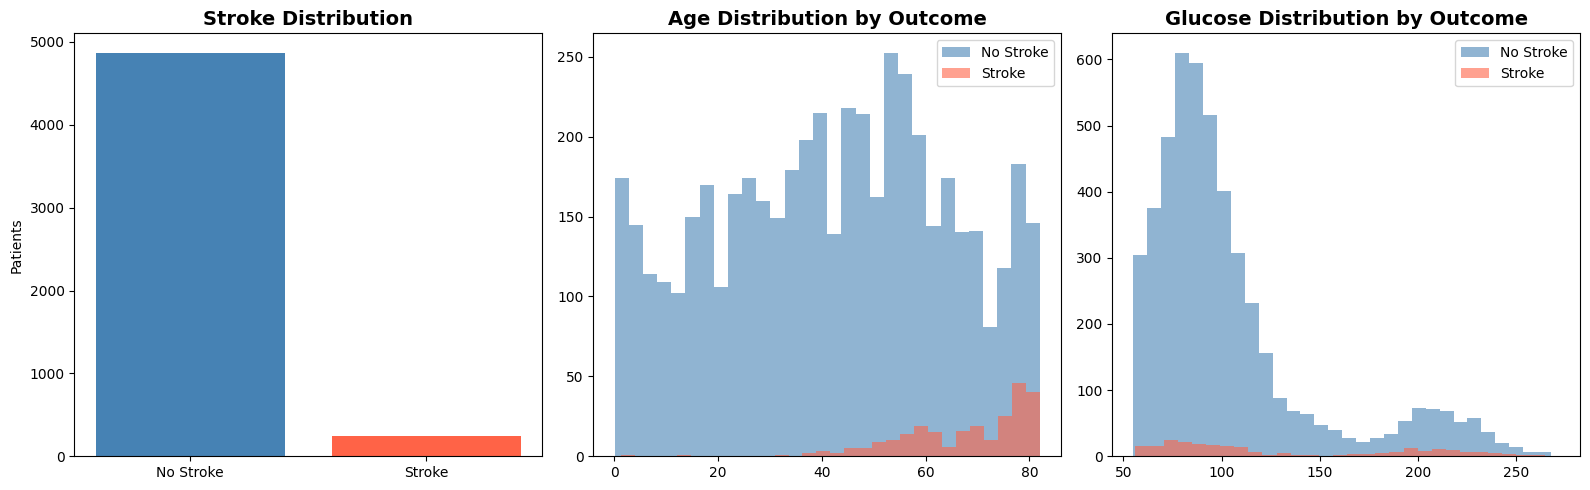

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1 - Stroke distribution
stroke_counts = df['stroke'].value_counts()
axes[0].bar(['No Stroke', 'Stroke'], stroke_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Stroke Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Patients')

# Chart 2 - Age distribution by outcome
axes[1].hist(df[df['stroke']==0]['age'], alpha=0.6, label='No Stroke', color='steelblue', bins=30)
axes[1].hist(df[df['stroke']==1]['age'], alpha=0.6, label='Stroke', color='tomato', bins=30)
axes[1].set_title('Age Distribution by Outcome', fontsize=14, fontweight='bold')
axes[1].legend()

# Chart 3 - Glucose distribution by outcome
axes[2].hist(df[df['stroke']==0]['avg_glucose_level'], alpha=0.6, label='No Stroke', color='steelblue', bins=30)
axes[2].hist(df[df['stroke']==1]['avg_glucose_level'], alpha=0.6, label='Stroke', color='tomato', bins=30)
axes[2].set_title('Glucose Distribution by Outcome', fontsize=14, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/charts/01_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Features and target
X = df.drop('stroke', axis=1)
y = df['stroke']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke'], zero_division=0))

Accuracy: 0.9393346379647749

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.94      1.00      0.97       960
      Stroke       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After SMOTE:", dict(zip(*np.unique(y_train_balanced, return_counts=True))))

Before SMOTE: {np.int64(0): np.int64(3901), np.int64(1): np.int64(187)}
After SMOTE: {np.int64(0): np.int64(3901), np.int64(1): np.int64(3901)}


In [38]:
# Retrain with balanced data
model_balanced = RandomForestClassifier(n_estimators=100, random_state=42)
model_balanced.fit(X_train_balanced, y_train_balanced)

# Evaluate
y_pred_balanced = model_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced, 
      target_names=['No Stroke', 'Stroke'],
      zero_division=0))

Accuracy: 0.9168297455968689

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.94      0.97      0.96       960
      Stroke       0.19      0.11      0.14        62

    accuracy                           0.92      1022
   macro avg       0.57      0.54      0.55      1022
weighted avg       0.90      0.92      0.91      1022

